# Cetacean binary LODO MLP — delphinid vs. non-delphinid

Pure MLP probe on cached Perch embeddings (`X_all.npy`).
**Binary**: `delphinid = 1` vs `non-delphinid = 0` (background + anthropogenic +
mysticetes + *Physeter macrocephalus*).

Label mapping
-------------
| `label_t2` | `label_t4` | → y |
|---|---|---|
| `background` | — | 0 |
| `anthropogenic` | — | 0 |
| `mysticete` | — | 0 |
| `odontocete` | `Physeter_macrocephalus` | 0 |
| `odontocete` | anything else (incl. `Delphinidae_unknown`) | **1** |
| null | — | *dropped* |

One fold per dataset (every dataset is held out once). Metrics reported on test:
AUC, AP, F1 @ best-val threshold, precision, recall, confusion matrix.
Learning curves show **train & val loss** plus **train & val accuracy** per epoch.


## 0. Setup

In [1]:
import os, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score,
    average_precision_score, roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42); torch.manual_seed(42)

os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {DEVICE}  torch: {torch.__version__}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")


device: cuda  torch: 2.5.1+cu121
GPU: NVIDIA L4


## 1. Paths and config

In [2]:
META_PATH = Path('/data2/mromaniuc/cet-det/alltogether/full_corpus_together/'
                 'mlp_runs/meta_all_with_taxonomy.parquet')
X_PATH    = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/'
                 'dim_red/projector_input/X_all.npy')
OUT_DIR   = Path('./mlp_runs/binary_delphinid_lodo')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Every dataset held out once — order doesn't matter
ALL_DATASETS = [
    'ALNITAK_CAVANILLES', 'Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE',
    'DRYAD', 'ECOSS_annot', 'ECOSS_enhanced', 'ECOSS_testtrain',
    'FREMANTLE', 'MONISH', 'OLTREMARE', 'WATKINS',
]

# MLP recipe (same as reference notebook)
HIDDEN       = (512, 256)
DROPOUT      = 0.3
LR           = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 1024
EPOCHS       = 40
PATIENCE     = 6
VAL_SIZE     = 0.10
SEED         = 42
MIN_POS_TEST = 1   # skip fold if test set has no positives

print(f"meta:    {META_PATH}  exists={META_PATH.exists()}")
print(f"X_all:   {X_PATH}     exists={X_PATH.exists()}")
print(f"outputs: {OUT_DIR.resolve()}")
print(f"folds:   {len(ALL_DATASETS)}")


meta:    /data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs/meta_all_with_taxonomy.parquet  exists=True
X_all:   /data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input/X_all.npy     exists=True
outputs: /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/binary_delphinid_lodo
folds:   12


## 2. Load corpus

In [3]:
meta_all = pd.read_parquet(META_PATH)
X_all    = np.load(X_PATH, mmap_mode='r')
print(f"meta_all : {len(meta_all):,} rows   cols={len(meta_all.columns)}")
print(f"X_all    : {X_all.shape}   dtype={X_all.dtype}")

assert 'row'       in meta_all.columns, "missing `row` column"
assert 'group_key' in meta_all.columns, "missing `group_key` column"
assert 'dataset'   in meta_all.columns, "missing `dataset` column"
assert meta_all['row'].max() < len(X_all), "row index out of bounds"
for c in ('label_t2', 'label_t4'):
    assert c in meta_all.columns, f"missing taxonomy column: {c}"

corpus_datasets = set(meta_all['dataset'].unique())
missing = [d for d in ALL_DATASETS if d not in corpus_datasets]
if missing:
    print(f"WARNING: datasets not found in corpus (will be skipped): {missing}")


meta_all : 247,630 rows   cols=64
X_all    : (247630, 1536)   dtype=float32


## 3. Build the binary label

`y = 1` for any odontocete that is NOT *Physeter macrocephalus* (strict
Delphinidae + *Delphinidae_unknown*). Everything else — background,
anthropogenic, mysticetes, sperm whale — is `y = 0`.


In [4]:
NON_DELPHINID_ODONTOCETES = {'Physeter_macrocephalus'}

def assign_binary(df: pd.DataFrame) -> pd.Series:
    t2 = df['label_t2']; t4 = df['label_t4']
    y  = pd.Series(np.full(len(df), np.nan), index=df.index)
    y[t2.isin(('background', 'anthropogenic', 'mysticete'))] = 0
    y[(t2 == 'odontocete') & t4.isin(NON_DELPHINID_ODONTOCETES)]  = 0
    y[(t2 == 'odontocete') & ~t4.isin(NON_DELPHINID_ODONTOCETES)] = 1
    return y

meta = meta_all.copy()
meta['y'] = assign_binary(meta)
meta = meta.dropna(subset=['y']).copy()
meta['y'] = meta['y'].astype(np.int64)

n_pos = int(meta['y'].sum())
n_neg = int((meta['y'] == 0).sum())
print(f"usable rows : {len(meta):,}  (dropped {len(meta_all)-len(meta):,} with no label_t2)")
print(f"delphinid=1 : {n_pos:,}  ({100*n_pos/len(meta):.1f}%)")
print(f"non-delph=0 : {n_neg:,}  ({100*n_neg/len(meta):.1f}%)")

print("\nper-dataset positive counts:")
ct = meta.groupby('dataset')['y'].agg(['sum','count'])
ct.columns = ['n_pos','n_total']
ct['pct'] = (100*ct['n_pos']/ct['n_total']).round(1)
print(ct.sort_values('n_pos', ascending=False).to_string())


usable rows : 247,630  (dropped 0 with no label_t2)
delphinid=1 : 32,379  (13.1%)
non-delph=0 : 215,251  (86.9%)

per-dataset positive counts:
                    n_pos  n_total    pct
dataset                                  
DCLDE_2026          21696   174538   12.4
DRYAD                2916     6770   43.1
OLTREMARE            2904    16860   17.2
DOLPHINFREE          1150     3290   35.0
Adriatic_Sea          942     1180   79.8
ALNITAK_CAVANILLES    675     5202   13.0
MONISH                588      617   95.3
WATKINS               475     1877   25.3
ECOSS_annot           466      752   62.0
FREMANTLE             332      332  100.0
ECOSS_enhanced        128      168   76.2
ECOSS_testtrain       107    36044    0.3


## 4. MLP probe

`1536 → 512 → 256 → 2` (binary cross-entropy via softmax), AdamW,
class-weighted loss, early-stop on val macro-F1.
Training loop now also tracks **accuracy** at each epoch so we can plot
four curves: train loss, val loss, train acc, val acc.


In [5]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 2))   # binary: class 0 = non-delph, 1 = delph
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


def train_mlp(Xtr, ytr, Xva, yva,
              hidden=HIDDEN, dropout=DROPOUT,
              lr=LR, weight_decay=WEIGHT_DECAY, batch_size=BATCH_SIZE,
              epochs=EPOCHS, patience=PATIENCE,
              class_weight=True, verbose=False):
    model = MLP(Xtr.shape[1], hidden=hidden, dropout=dropout).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    if class_weight:
        counts = np.bincount(ytr, minlength=2).astype(np.float32)
        w = counts.sum() / (2 * np.clip(counts, 1, None))
        crit = nn.CrossEntropyLoss(
            weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))
        print(f"  class weights: non-delphinid={w[0]:.3f}  delphinid={w[1]:.3f}")
    else:
        crit = nn.CrossEntropyLoss()

    tr_dl = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
                       batch_size=batch_size, shuffle=True,  num_workers=0)
    va_dl = DataLoader(TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva)),
                       batch_size=batch_size, shuffle=False, num_workers=0)

    best_f1, best_state, bad = -1.0, None, 0
    history = []

    for ep in range(1, epochs + 1):
        # ── train ──
        model.train()
        tr_loss, tr_correct, n = 0.0, 0, 0
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss   = crit(logits, yb)
            loss.backward(); opt.step()
            tr_loss    += loss.item() * xb.size(0)
            tr_correct += (logits.argmax(1) == yb).sum().item()
            n          += xb.size(0)
        tr_loss /= n
        tr_acc   = tr_correct / n

        # ── val ──
        model.eval()
        va_loss, va_correct, va_n = 0.0, 0, 0
        preds, trues = [], []
        with torch.no_grad():
            for xb, yb in va_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits  = model(xb)
                va_loss += crit(logits, yb).item() * xb.size(0)
                va_correct += (logits.argmax(1) == yb).sum().item()
                va_n    += xb.size(0)
                preds.append(logits.argmax(1).cpu().numpy())
                trues.append(yb.cpu().numpy())
        va_loss /= va_n
        va_acc   = va_correct / va_n
        preds = np.concatenate(preds); trues = np.concatenate(trues)
        va_f1 = f1_score(trues, preds, average='macro', zero_division=0)

        history.append({
            'epoch':    ep,
            'tr_loss':  float(tr_loss),  'va_loss':  float(va_loss),
            'tr_acc':   float(tr_acc),   'va_acc':   float(va_acc),
            'va_macro_f1': float(va_f1),
        })
        if verbose:
            print(f"  ep{ep:02d}  tr_loss={tr_loss:.4f}  va_loss={va_loss:.4f}"
                  f"  tr_acc={tr_acc:.4f}  va_acc={va_acc:.4f}  va_f1={va_f1:.4f}")

        if va_f1 > best_f1 + 1e-4:
            best_f1   = va_f1
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, float(best_f1)


def predict_proba(model, X, batch_size=4096):
    """Returns softmax probabilities shape (N, 2)."""
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            logits = model(torch.from_numpy(X[i:i+batch_size]).to(DEVICE))
            out.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(out, axis=0)


def split_train_val(meta_subset, val_size=VAL_SIZE, random_state=SEED):
    gss = GroupShuffleSplit(n_splits=1, test_size=val_size,
                             random_state=random_state)
    tr_pos, va_pos = next(gss.split(np.zeros(len(meta_subset)),
                                    groups=meta_subset['group_key'].values))
    return tr_pos, va_pos


## 5. One LODO fold

`run_fold(held_out)` trains, evaluates, saves artefacts and returns a summary
dict (including the model, scaler, and raw predictions for later inspection).


In [6]:
def run_fold(held_out: str, verbose_epochs: bool = False) -> dict | None:
    train_pool = meta[meta['dataset'] != held_out].copy()
    test_pool  = meta[meta['dataset'] == held_out].copy()

    n_pos_test = int(test_pool['y'].sum())
    n_pos_train = int(train_pool['y'].sum())

    print(f"  [{held_out}]  train={len(train_pool):,}  test={len(test_pool):,}"
          f"  pos_train={n_pos_train:,}  pos_test={n_pos_test:,}")

    if n_pos_test < MIN_POS_TEST:
        print(f"  [{held_out}] no positives in test — skipping")
        return None
    if n_pos_train < 2:
        print(f"  [{held_out}] no positives in training pool — skipping")
        return None

    tr_pos, va_pos = split_train_val(train_pool)
    rows_tr = train_pool.iloc[tr_pos]['row'].values
    rows_va = train_pool.iloc[va_pos]['row'].values
    rows_te = test_pool['row'].values

    Xtr = np.asarray(X_all[rows_tr], dtype=np.float32)
    Xva = np.asarray(X_all[rows_va], dtype=np.float32)
    Xte = np.asarray(X_all[rows_te], dtype=np.float32)
    ytr = train_pool.iloc[tr_pos]['y'].values.astype(np.int64)
    yva = train_pool.iloc[va_pos]['y'].values.astype(np.int64)
    yte = test_pool['y'].values.astype(np.int64)

    # Standardise on train
    sc   = StandardScaler().fit(Xtr)
    Xtr_s = sc.transform(Xtr).astype(np.float32)
    Xva_s = sc.transform(Xva).astype(np.float32)
    Xte_s = sc.transform(Xte).astype(np.float32)

    t0 = time.time()
    model, history, best_va_f1 = train_mlp(
        Xtr_s, ytr, Xva_s, yva,
        class_weight=True, verbose=verbose_epochs,
    )
    elapsed = time.time() - t0

    # ── Test ──
    probs_te = predict_proba(model, Xte_s)   # (N, 2)
    prob_pos = probs_te[:, 1]                # P(delphinid)

    # Threshold: sweep val probs, pick best F1
    val_probs = predict_proba(model, Xva_s)[:, 1]
    best_thresh, best_thresh_f1 = 0.5, -1.0
    for t in np.linspace(0.05, 0.95, 37):
        f1 = f1_score(yva, (val_probs >= t).astype(int),
                      average='macro', zero_division=0)
        if f1 > best_thresh_f1:
            best_thresh_f1, best_thresh = f1, float(t)

    ypr = (prob_pos >= best_thresh).astype(int)

    # Metrics
    auc = float(roc_auc_score(yte, prob_pos))
    ap  = float(average_precision_score(yte, prob_pos))
    p, r, f, _ = precision_recall_fscore_support(
        yte, ypr, average='binary', zero_division=0)
    acc = float((ypr == yte).mean())
    cm  = confusion_matrix(yte, ypr, labels=[0, 1])

    # Persist
    fold_out = OUT_DIR / held_out
    fold_out.mkdir(parents=True, exist_ok=True)
    np.save(fold_out / 'probs_te.npy', prob_pos.astype(np.float32))
    np.save(fold_out / 'ypr_te.npy',   ypr.astype(np.int32))
    np.save(fold_out / 'yte.npy',      yte.astype(np.int32))
    np.save(fold_out / 'rows_te.npy',  rows_te.astype(np.int64))
    torch.save({
        'model_state':  model.state_dict(),
        'scaler_mean':  sc.mean_,
        'scaler_scale': sc.scale_,
        'held_out':     held_out,
        'threshold':    best_thresh,
    }, fold_out / 'model.pt')

    summary = {
        'held_out':      held_out,
        'n_train':       int(len(rows_tr)),
        'n_val':         int(len(rows_va)),
        'n_test':        int(len(rows_te)),
        'n_pos_train':   int(n_pos_train),
        'n_pos_test':    int(n_pos_test),
        'val_macro_f1':  float(best_va_f1),
        'test_auc':      auc,
        'test_ap':       ap,
        'test_f1':       float(f),
        'test_precision':float(p),
        'test_recall':   float(r),
        'test_accuracy': acc,
        'best_threshold':best_thresh,
        'confusion_matrix': cm.tolist(),
        'history':       history,
        'elapsed_s':     float(elapsed),
    }
    with open(fold_out / 'summary.json', 'w') as fh:
        json.dump(summary, fh, indent=2)

    # keep live objects for plotting
    summary['_model']    = model
    summary['_scaler']   = sc
    summary['_yte']      = yte
    summary['_ypr']      = ypr
    summary['_prob_pos'] = prob_pos
    summary['_cm']       = cm
    return summary


## 6. Run all LODO folds

One fold per dataset (~seconds each on GPU). Results are collected in `results`
dict keyed by dataset name.


In [7]:
results = {}
for ds in tqdm(ALL_DATASETS, desc='LODO folds'):
    try:
        r = run_fold(ds, verbose_epochs=False)
        if r is not None:
            results[ds] = r
    except Exception as e:
        print(f"  [{ds}] FAILED: {e}")
        import traceback; traceback.print_exc()

print(f"\n{'═'*60}")
print(f"  {len(results)}/{len(ALL_DATASETS)} folds completed")
print(f"{'═'*60}")


LODO folds:   0%|          | 0/12 [00:00<?, ?it/s]

  [ALNITAK_CAVANILLES]  train=242,428  test=5,202  pos_train=31,704  pos_test=675
  class weights: non-delphinid=0.574  delphinid=3.859
  [Adriatic_Sea]  train=246,450  test=1,180  pos_train=31,437  pos_test=942
  class weights: non-delphinid=0.570  delphinid=4.047
  [DCLDE_2026]  train=73,092  test=174,538  pos_train=10,683  pos_test=21,696
  class weights: non-delphinid=0.587  delphinid=3.358
  [DOLPHINFREE]  train=244,340  test=3,290  pos_train=31,229  pos_test=1,150
  class weights: non-delphinid=0.572  delphinid=3.971
  [DRYAD]  train=240,860  test=6,770  pos_train=29,463  pos_test=2,916
  class weights: non-delphinid=0.570  delphinid=4.051
  [ECOSS_annot]  train=246,878  test=752  pos_train=31,913  pos_test=466
  class weights: non-delphinid=0.574  delphinid=3.859
  [ECOSS_enhanced]  train=247,462  test=168  pos_train=32,251  pos_test=128
  class weights: non-delphinid=0.574  delphinid=3.879
  [ECOSS_testtrain]  train=211,586  test=36,044  pos_train=32,272  pos_test=107
  class w

## 7. Master summary

In [8]:
rows = []
for ds, s in results.items():
    rows.append({
        'held_out':      s['held_out'],
        'n_train':       s['n_train'],
        'n_test':        s['n_test'],
        'n_pos_test':    s['n_pos_test'],
        'pct_pos_test':  round(100*s['n_pos_test']/s['n_test'], 1),
        'val_macro_f1':  round(s['val_macro_f1'],  4),
        'test_auc':      round(s['test_auc'],       4),
        'test_ap':       round(s['test_ap'],        4),
        'test_f1':       round(s['test_f1'],        4),
        'test_precision':round(s['test_precision'], 4),
        'test_recall':   round(s['test_recall'],    4),
        'test_accuracy': round(s['test_accuracy'],  4),
        'threshold':     round(s['best_threshold'], 2),
        'elapsed_s':     round(s['elapsed_s'],      1),
    })

summary_df = pd.DataFrame(rows).sort_values('test_auc', ascending=False)
summary_path = OUT_DIR / 'lodo_summary.csv'
summary_df.to_csv(summary_path, index=False)
print(f"saved → {summary_path}\n")
summary_df


saved → mlp_runs/binary_delphinid_lodo/lodo_summary.csv



,held_out,n_train,n_test,n_pos_test,pct_pos_test,val_macro_f1,test_auc,test_ap,test_f1,test_precision,test_recall,test_accuracy,threshold,elapsed_s
6,ECOSS_enhanced,219516,168,128,76.2,0.8435,1.0000,1.0000,0.9881,1.0000,0.9766,0.9821,0.68,111.7
7,ECOSS_testtrain,191702,36044,107,0.3,0.8509,0.9819,0.7182,0.3647,0.2308,0.8692,0.9910,0.65,60.2
1,Adriatic_Sea,222878,1180,942,79.8,0.8726,0.8823,0.9682,0.6676,0.9916,0.5032,0.6000,0.60,115.0
11,WATKINS,218727,1877,475,25.3,0.8476,0.8693,0.6435,0.6744,0.5569,0.8547,0.7912,0.68,77.8
3,DOLPHINFREE,220540,3290,1150,35.0,0.8579,0.8593,0.7384,0.7099,0.5930,0.8843,0.7474,0.55,102.9
10,OLTREMARE,207847,16860,2904,17.2,0.8526,0.8562,0.7567,0.7041,0.8362,0.6081,0.9120,0.68,76.1
4,DRYAD,218499,6770,2916,43.1,0.8495,0.8550,0.8488,0.7491,0.7266,0.7730,0.7770,0.72,72.5
2,DCLDE_2026,63694,174538,21696,12.4,0.6087,0.6998,0.3180,0.3422,0.3285,0.3571,0.8293,0.95,11.2
5,ECOSS_annot,225249,752,466,62.0,0.8574,0.5307,0.7087,0.5014,0.6932,0.3927,0.5160,0.72,52.1
0,ALNITAK_CAVANILLES,216635,5202,675,13.0,0.8652,0.5296,0.1669,0.1249,0.2842,0.0800,0.8545,0.68,82.1


## 8. Confusion matrices

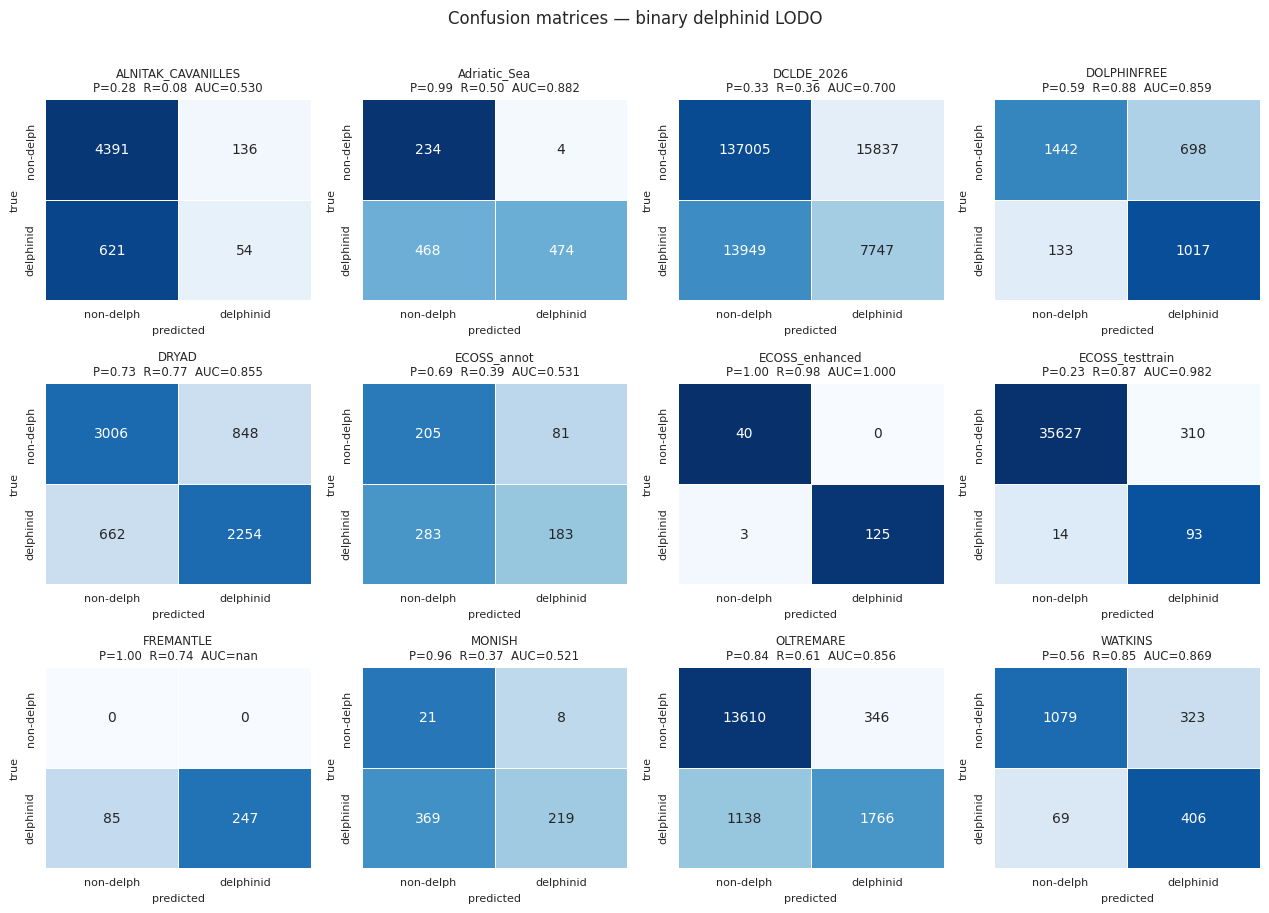

In [9]:
n = len(results)
ncols = 4
nrows = -(-n // ncols)   # ceiling division
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols*3.2, nrows*3.0),
                          squeeze=False)
axes_flat = axes.flat

for ax, (ds, s) in zip(axes_flat, results.items()):
    cm = np.array(s['_cm'])
    cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
    labels = ['non-delph', 'delphinid']
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax,
                vmin=0, vmax=1, linewidths=0.5)
    p = s['test_precision']; r = s['test_recall']
    ax.set_title(f"{ds}\nP={p:.2f}  R={r:.2f}  AUC={s['test_auc']:.3f}",
                 fontsize=8.5)
    ax.set_xlabel('predicted', fontsize=8); ax.set_ylabel('true', fontsize=8)
    ax.tick_params(labelsize=8)

# hide empty axes
for ax in list(axes_flat)[len(results):]:
    ax.set_visible(False)

plt.suptitle('Confusion matrices — binary delphinid LODO', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. AUC and AP by fold

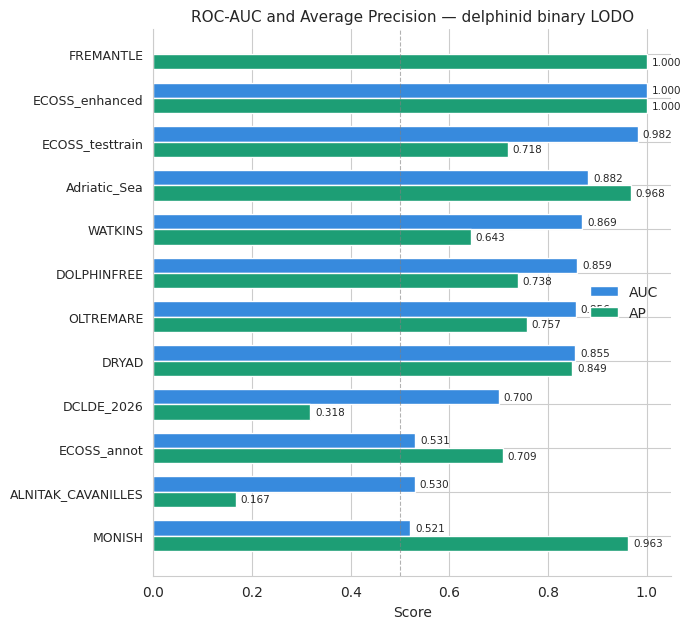

In [10]:
df = summary_df.sort_values('test_auc', ascending=True)

fig, ax = plt.subplots(figsize=(7, max(3, 0.45 * len(df) + 1)))
y = np.arange(len(df))
h = 0.35
ax.barh(y + h/2, df['test_auc'], h, label='AUC',  color='#378ADD')
ax.barh(y - h/2, df['test_ap'],  h, label='AP',   color='#1D9E75')
ax.set_yticks(y); ax.set_yticklabels(df['held_out'], fontsize=9)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Score')
ax.set_title('ROC-AUC and Average Precision — delphinid binary LODO', fontsize=11)
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.legend(frameon=False)
for i, (auc, ap) in enumerate(zip(df['test_auc'], df['test_ap'])):
    ax.text(min(auc+0.01, 1.04), i+h/2, f'{auc:.3f}', va='center', fontsize=7.5)
    ax.text(min(ap +0.01, 1.04), i-h/2, f'{ap:.3f}',  va='center', fontsize=7.5)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / 'auc_ap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Learning curves

Each panel shows **4 curves**: train loss, val loss (left axis) and train
accuracy, val accuracy (right axis).


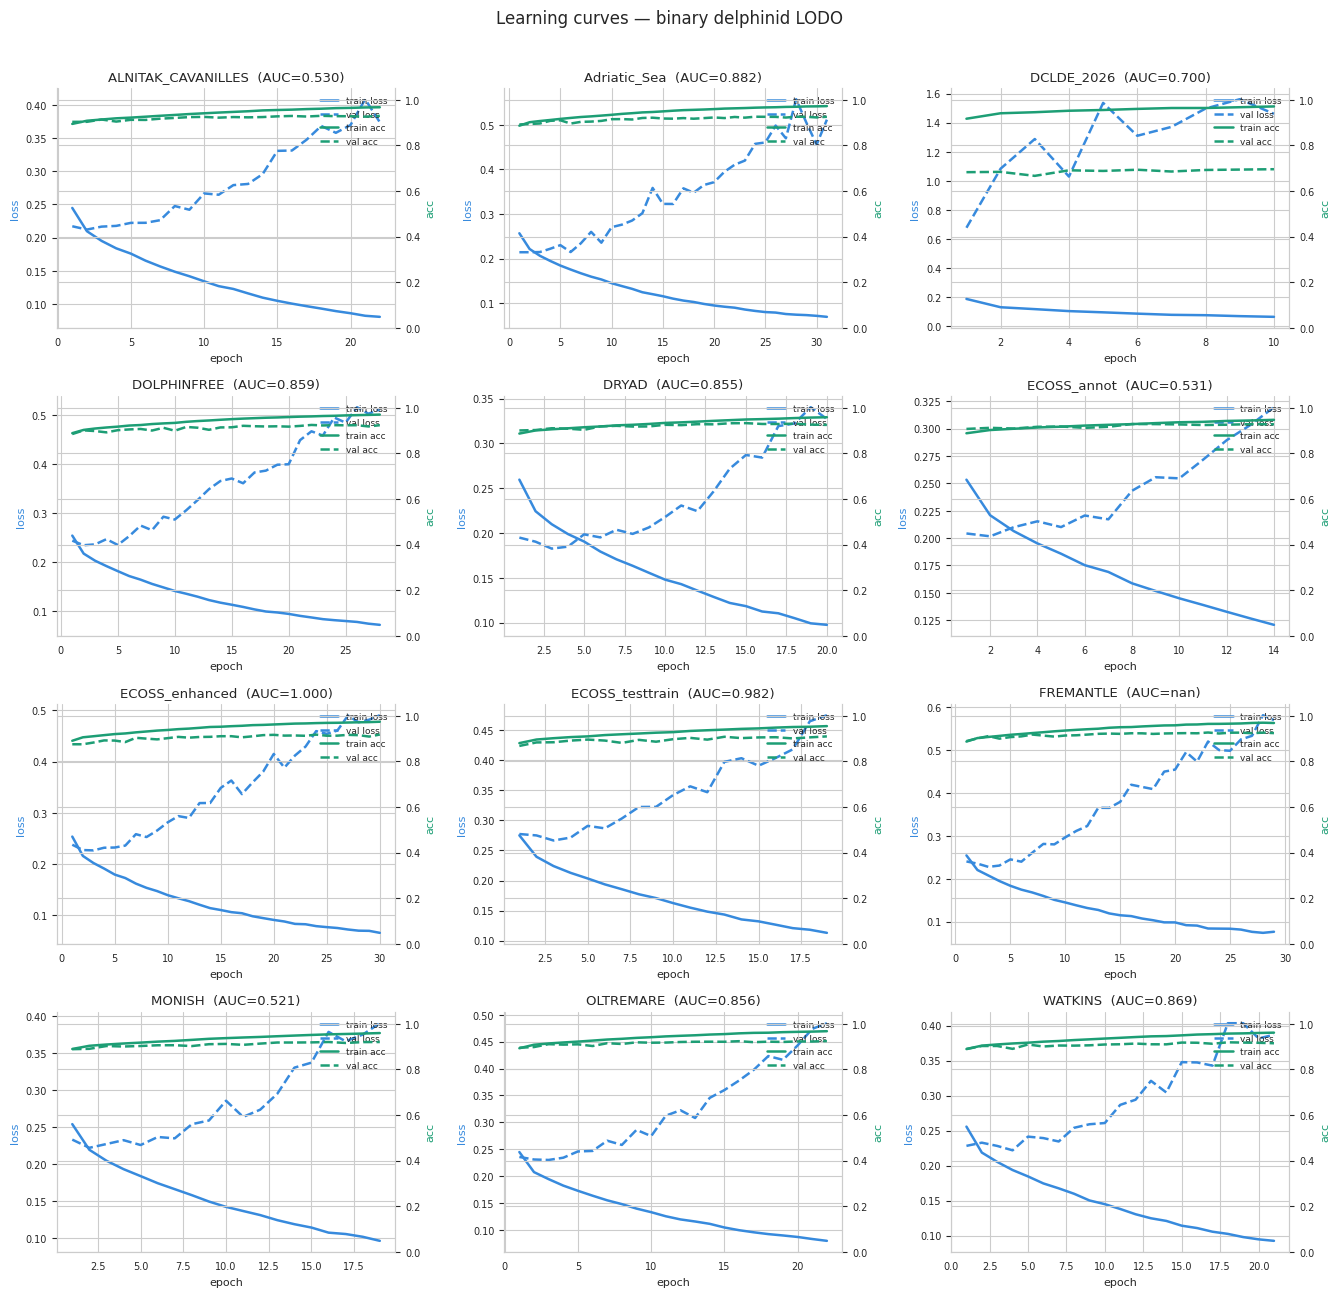

In [11]:
n      = len(results)
ncols  = 3
nrows  = -(-n // ncols)

BLUE  = '#378ADD'
TEAL  = '#1D9E75'
CORAL = '#E07B54'
GOLD  = '#D4AC0D'

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols*4.5, nrows*3.2),
                          squeeze=False)
axes_flat = axes.flat

for ax, (ds, s) in zip(axes_flat, results.items()):
    h   = pd.DataFrame(s['history'])
    ax2 = ax.twinx()

    # loss curves (left axis)
    ax.plot(h['epoch'], h['tr_loss'], color=BLUE,  lw=1.8, label='train loss')
    ax.plot(h['epoch'], h['va_loss'], color=BLUE,  lw=1.8, linestyle='--',
            label='val loss')

    # accuracy curves (right axis)
    ax2.plot(h['epoch'], h['tr_acc'], color=TEAL,  lw=1.8, label='train acc')
    ax2.plot(h['epoch'], h['va_acc'], color=TEAL,  lw=1.8, linestyle='--',
             label='val acc')

    ax.set_title(f"{ds}  (AUC={s['test_auc']:.3f})", fontsize=9.5)
    ax.set_xlabel('epoch', fontsize=8)
    ax.set_ylabel('loss',  color=BLUE, fontsize=8)
    ax2.set_ylabel('acc',  color=TEAL, fontsize=8)
    ax2.set_ylim(0, 1.05)
    ax.tick_params(labelsize=7)
    ax2.tick_params(labelsize=7)
    ax.spines[['top']].set_visible(False)
    ax2.spines[['top']].set_visible(False)

    # combined legend
    lines  = ax.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, frameon=False, fontsize=6.5, loc='upper right')

for ax in list(axes_flat)[len(results):]:
    ax.set_visible(False)

plt.suptitle('Learning curves — binary delphinid LODO', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. ROC curves (all folds overlay)

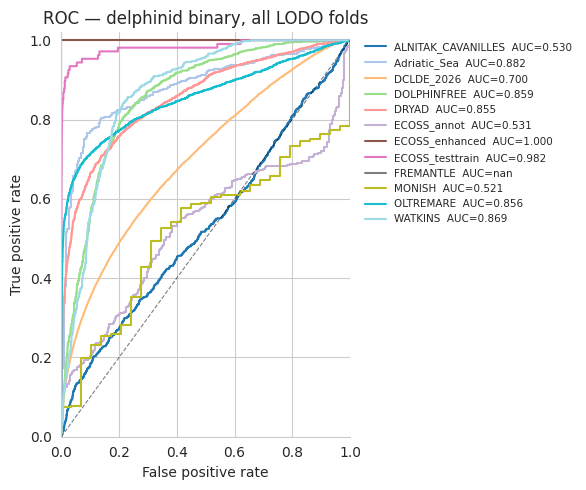

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
cmap = plt.cm.get_cmap('tab20', len(results))

for i, (ds, s) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(s['_yte'], s['_prob_pos'])
    ax.plot(fpr, tpr, lw=1.5, color=cmap(i),
            label=f"{ds}  AUC={s['test_auc']:.3f}")

ax.plot([0,1],[0,1], 'k--', lw=0.8, alpha=0.5)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC — delphinid binary, all LODO folds')
ax.legend(fontsize=7.5, frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
